- https://github.com/wooozihui/GlitchMiner
- https://www.zhihu.com/question/2017049686331127666/answer/2036149386116342692

### Glitch Tokens（故障Token）

- examples
    - Pony Alpha（glm-5）：锅内倒入植物油烧热（菜谱网站）
    - gpt-4o（o200k）：给主人留下些什么吧（早期 QQ 空间留言板默认文案）
- Polluted Token / Tokenizer-Model Mismatch
    - PoC：Polluted Chinese tokens
- 表现：彻底地胡言乱语，与幻觉
    - Attention Collapse（注意力坍缩） 或 Semantic Void（语义真空）。
    - generation：无法生成 `嘉祺`
- 原因分析
    - Tokenizer 数据集与 LLM 预训练数据集的不一致
        - Tokenizer 是在数据 A 上训练的，LLM 的 Transformer 本体是在经过清洗的高质量数据 B 上进行预训练的
    - 导致欠拟合的 token Embedding：导致该 Token 对应的 Embedding Vector（嵌入向量） 没有得到充分的梯度更新。它可能还停留在初始化时的随机状态，或者因为样本太少，被推到了向量空间中一个莫名其妙的角落。（`后训练过程中该区域的向量空间已被挤压和污染。`）
    - 处理输入 `“ [Glitch] ” 什么意思` 时，是一个 token 一个 token 往后读的。是当前正在被处理的 token。比如模型读到了 “意思” 这个词，它现在的任务是：“我要搞清楚‘意思’是指谁的意思？”它发出了一个查询向量 $Q_{\text{意思}}$。
        - Key ($K$) 是谁？是上下文里的所有 token。包括 `[Start]`、`“`、`[Glitch]`、`”`、什么。它们各自拿出了自己的键向量：$K_{\text{Start}}, K_{\text{“}}, K_{\text{Glitch}}, K_{\text{”}}...$
        - $Q_{\text{意思}}$ 要跟前面每一个 $K$ 算内积（Dot Product），也就是算相似度分数（Attention Score）。

#### embedding lookup table vs. lm_head

$$
\text{token id}
\overset{E}{\longrightarrow}
x
\overset{\text{Transformer}}{\longrightarrow}
h
\overset{U}{\longrightarrow}
z
\overset{\text{softmax}}{\longrightarrow}
p.
$$

- input embedding lookup table（vocabulary embedding）：$E \in \mathbb{R}^{V \times d}$，
    - $\text{token id} \rightarrow \text{embedding vector}$
    - 它的作用是把 token id 变成向量。比如 token id 是 i，输入端直接查表：$x_i = E_i.$
    - 这一步像“查字典”：看到编号 $i$，取出第 $i$ 行向量。
    - $\text{token id} \longrightarrow \text{向量}$
- hidden state：
    - $h_t \in \mathbb{R}^{d}$（contextual embedding）
- lm_head：output embedding / unembedding，hidden state 到词表 logits 的输出投影层
    - $\text{hidden state} \rightarrow \text{vocab logits} \rightarrow \text{probability over tokens} \rightarrow \text{next token id}$
        - $h_t\xrightarrow{\;z_t = W_U h_t + b\;}z_t\xrightarrow{\;p_t = \mathrm{softmax}(z_t)\;}p_t\xrightarrow{\;x_{t+1} \sim p_t\;}x_{t+1}$ 
    - $W_{\text{out}} \in \mathbb{R}^{V \times d}$
    - 它把最后一层 hidden state 映射成词表上每个 token 的分数：$z_i = h_t^\top W_{\text{out}, i}.$
    - 这里的 $W_{\text{out}, i}$ 是第 i 个 token 的输出向量，也常被叫做 output embedding、unembedding、output projection row。
    - $\text{hidden state} \longrightarrow \text{每个 token 的 logit}$
- 开源 llm
    - gpt2：weight tying（tie，权重绑定）
        - wte：word token embedding
        - lm_head
    - qwen3：https://huggingface.co/Qwen/Qwen3-0.6B/blob/main/config.json
        - tie：true
        - 小尺寸模型为了降参数，大尺寸的qwen不复用的
    - k2.5: https://huggingface.co/moonshotai/Kimi-K2.5/blob/main/config.json
        - untied,

#### training analysis

- $\theta = \arccos(c).$
    - $c = 0.9568$ => $\theta \approx 16.88^\circ.$
- $d_{\text{unit}}=\left\|\frac{w^{\text{base}}}{\|w^{\text{base}}\|}-\frac{w^{\text{SFT}}}{\|w^{\text{SFT}}\|}\right\|=\sqrt{2(1-c)}.$
    - $d_{\text{unit}}=\sqrt{2(1-0.9568)}\approx 0.2939.$
- logit 视角
    - $z_i = h^\top w_i=\|h\| \|w_i\| \cos(\alpha).$
    - cosine 只看方向，norm 看长度。方向接近但长度变大，token 的 logit 可能明显升高；方向接近但长度变小，token 可能更难被生成。综合方向和长度后，相对 L2 变化为：
- embedding gradient
    - sft
        - 语言模型的交叉熵损失为 $L = -\log p_y,$，其中 $p_i =\frac{\exp(z_i)}{\sum_j \exp(z_j)},\quad z_i = h^\top w_i.$
        - 对 lm_head 第 $i$ 行的梯度为：$\nabla_{w_i} L=(p_i - \mathbf{1}_{i=y})h.$
        - 当 token $i$ 是目标输出 $y$ 时，它的 lm_head 行会被强烈更新；当它频繁出现在 SFT 答案、模板、姓名、角色标签、工具调用片段中时，更新会更加集中。若“嘉棋”这个 token 在 SFT 数据中有特殊分布，它的 lm_head 行出现 outlier 式变化就合理。
    - rl
        - $a_t \sim \pi_\theta(\cdot \mid s_t), s_t = (x, a_{<t}).$
        - $L_{\text{RL}}=-\sum_t A_t \log \pi_\theta(a_t \mid s_t).$
        - $\nabla_{w_i} L_{\text{RL}}=A_t\left(p_i - \mathbf{1}_{i=a_t}\right)h_t.$
    - sft vs. rl
        - $y_t \quad \longrightarrow \quad a_t,$
        - $1 \quad \longrightarrow \quad A_t.$
        - 如果 $A_t > 0$，说明模型这一步采样的 token 对最终奖励有正贡献。梯度下降会提高该 token 的 logit，降低其他竞争 token 的 logit。
        - SFT 的老师给定明确答案：$\text{正确 token} = y_t.$
        - RL 的老师只给结果评价：$\text{这条回答总体好不好} = R.$
        - 所以 SFT 是“逐 token 对答案”，RL 是“根据整段回答的得分，回头调整每个被采样 token 的概率”。这也解释了 RL 为什么更容易造成某些 lm_head 行向量的异常变化：它会强化被高奖励轨迹反复采样的 token，同时惩罚低奖励轨迹中的 token。
- 只比较 lm_head 行向量，只能说明输出矩阵本身变了。模型最终输出变化还来自 hidden state 的变化。SFT 前后的 logit 差可以拆成：
    - $z_i^{\text{SFT}} - z_i^{\text{base}}=(h^{\text{SFT}})^\top w_i^{\text{SFT}}-(h^{\text{base}})^\top w_i^{\text{base}}.$
    - $\Delta h = h^{\text{SFT}} - h^{\text{base}},\quad\Delta w_i = w_i^{\text{SFT}} - w_i^{\text{base}},$
    - $\Delta z_i\approx(h^{\text{base}})^\top \Delta w_i+(\Delta h)^\top w_i^{\text{base}}+(\Delta h)^\top \Delta w_i.$

#### gradient descent

- 对 $w_i$ 的梯度
  
$$
\begin{split}
&\nabla_{w_i}L=(p_i-\mathbf{1}_{i=y})h.\\
&w_i \leftarrow w_i-\eta(p_i-\mathbf{1}_{i=y})h.
\end{split}
$$

- 当 $i=y$ 时，也就是 token $i$ 是当前位置的正确下一个 token：
    - $\Delta w_i=\eta(1-p_i)h.$
    - 会把 $w_i$ 往 $h$ 的方向拉，直观上，模型在学习：“遇到类似这个 hidden state 的上下文时，应该更容易输出 token $i$
- 当 $i\neq y$，也就是 token $i$ 不是正确答案：
    - $\Delta w_i=-\eta p_i h.$
    - 这会把 $w_i$ 往远离 $h$ 的方向推。直观上，模型在学习：“这个上下文下不该输出 token $i$。”
- 嘉祺”相关数据很少时，确实会减少正向目标更新，但仍有几类更新来源。
    - 第一，softmax 的负类更新一直存在。即使“嘉祺”从未作为 label 出现，只要模型在某些上下文里给它分配了概率 $p_i$，它的 lm_head 行就会收到梯度。对于 $V=200{,}000$ ，若概率接近均匀分布，$p_i\approx \frac{1}{200000}=5\times 10^{-6}.$
    - 第二，一个正样本的影响通常很大。目标 token 出现一次时，更新系数约为 $1-p_i\approx 1.$，而均匀负类更新的单步系数约为 $5\times 10^{-6}.$
    - 总更新粗略写成：$\Delta w_i\approx\eta\sum_{t:y_t=i}(1-p_i(t))h_t-\eta\sum_{t:y_t\neq i}p_i(t)h_t.$
        - 第一项是正类拉近，第二项是负类推远。某个 token 数据少，只能说明第一项可能小；第二项仍然存在。

### blog

- 对比全词表的 embed_tokens norm 分布
    - 对比全词表的 embed_tokens norm 分布，token 190467（“嘉祺”）的向量范数落在正常分布范围内，未出现未训练 token 常见的异常小值的现象，表明该 token 在预训练阶段已被充分学习
- 余弦相似度大幅下降且 Norm 变化很大
    - 后训练的对话数据里，包含“嘉祺”的样本不到 5 条，导致后训练过程中，“嘉祺”这个 token 几乎没有被模型练习过，而后训练时大量频繁出现的 token（如 tool_call 标记、代码符号）会持续更新自己周围的向量空间，把“嘉祺”这种没被练到的低频 token 挤压到了不该去的方向。到了该输出名字的时候，模型说不出“嘉祺”，转而选了发音相近的“佳琪”、“琪琪”等被练习过的 token。
- 退化 token 大致分为四类：预训练阶段的特殊标记（如代码填充符号）、LaTeX 公式与维基百科源码标记、中文 SEO 垃圾内容、以及日文口语和博客模板表达（最大类别，占比 40%+）。其中特殊标记和格式标记的退化是预期内的，这些 token 在预训练和后训练的用途本就不同。
    - 退化机制完全一致：预训练时学会了，后训练时因为没有被练到而遗忘了。
- 此前模型在处理日语对话时，偶尔会在回答中混入俄语或韩语字符
    - 由于后训练数据中日文内容的覆盖严重不足，导致这些日文 token 参数发生漂移，与其他语言的 token 在向量空间中发生混淆，既可能导致日文 token 在不该出现时被错误激活（语言混杂），也可能导致与之空间相邻的低频中文 token（如“嘉祺”）被挤出正常的生成概率范围（token 遗忘）。
- 修复思路就很清晰了：确保每个 token 在后训练阶段都能被练到。
    - 我们构造了一份覆盖全词表的合成数据，核心思想是：通过一个简单的复读任务，为全词表建立一个生成频率的“下限保障”，防止任何 token 因为完全缺失而退化，且效果是显著的：

### 检测与识别

- embedding norm
- “复读机测试” (Repetition Task)
    - 如果是一个 Glitch token，由于其 Attention 坍缩或语义崩坏，模型会拒绝复读，并输出完全无关的幻觉内容。

In [20]:
import torch
import pandas as pd
from safetensors import safe_open
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer, AutoConfig

base_id = "Qwen/Qwen2.5-1.5B"
sft_id  = "Qwen/Qwen2.5-1.5B-Instruct"

tok = AutoTokenizer.from_pretrained(sft_id)
cfg_base = AutoConfig.from_pretrained(base_id)
cfg_sft = AutoConfig.from_pretrained(sft_id)

print("base tied:", cfg_base.tie_word_embeddings)
print("sft tied :", cfg_sft.tie_word_embeddings)
print("vocab    :", cfg_sft.vocab_size)

def load_lm_head_or_tied_embedding(repo_id):
    path = hf_hub_download(repo_id, "model.safetensors")
    with safe_open(path, framework="pt", device="cpu") as f:
        keys = set(f.keys())
        key = "lm_head.weight" if "lm_head.weight" in keys else "model.embed_tokens.weight"
        W = f.get_tensor(key).float()
    return W, key

W0, key0 = load_lm_head_or_tied_embedding(base_id)
W1, key1 = load_lm_head_or_tied_embedding(sft_id)

print(key0, W0.shape)
print(key1, W1.shape)

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/.no_exist'
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/.no_exist'
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/.no_exist'


base tied: True
sft tied : True
vocab    : 151936
model.embed_tokens.weight torch.Size([151936, 1536])
model.embed_tokens.weight torch.Size([151936, 1536])


- $W^0 \in \mathbb{R}^{V \times d}$: base, $W^1 \in \mathbb{R}^{V \times d}$: 为 SFT / Instruct 后权重。
- 第 $i$ 个 token 的行向量为：$w_i^0,\; w_i^1 \in \mathbb{R}^{d}.$
- norm 
    - $n_i^0 = \|w_i^0\|_2,\quad n_i^1 = \|w_i^1\|_2$
    - $\rho_i = \frac{n_i^1}{n_i^0}$（看 norm 被放大还是压低）
    - $c_i =\frac{(w_i^0)^\top w_i^1}{\|w_i^0\|_2\|w_i^1\|_2}$（看方向是否旋转，`[-1,1]`）
        - $\theta_{\text{rad}} = \arccos(\cos(\theta))$（`[0, pi]`）
    - $r_i =\frac{\|w_i^1 - w_i^0\|_2}{\|w_i^0\|_2}$（看整体相对位移。）
- 这里用 robust z-score 看 norm ratio 的异常程度。普通 z-score 容易被极端 token 拉偏，robust z-score 用 median 和 MAD：
    - $z_i =0.6745 \cdot\frac{x_i - \operatorname{median}(x)}{\operatorname{median}(|x-\operatorname{median}(x)|)}.$

In [2]:
eps = 1e-12

n0 = W0.norm(dim=1)
n1 = W1.norm(dim=1)

cos = torch.nn.functional.cosine_similarity(W0, W1, dim=1, eps=eps).clamp(-1, 1)
angle_deg = torch.rad2deg(torch.acos(cos))

norm_ratio = n1 / (n0 + eps)
rel_l2 = (W1 - W0).norm(dim=1) / (n0 + eps)

df = pd.DataFrame({
    "id": range(W0.shape[0]),
    "base_norm": n0.numpy(),
    "sft_norm": n1.numpy(),
    "norm_ratio": norm_ratio.numpy(),
    "cos": cos.numpy(),
    "angle_deg": angle_deg.numpy(),
    "rel_l2": rel_l2.numpy(),
})

special_ids = set(tok.all_special_ids)
df["special"] = df["id"].isin(special_ids)
df = df[~df["special"]].copy()

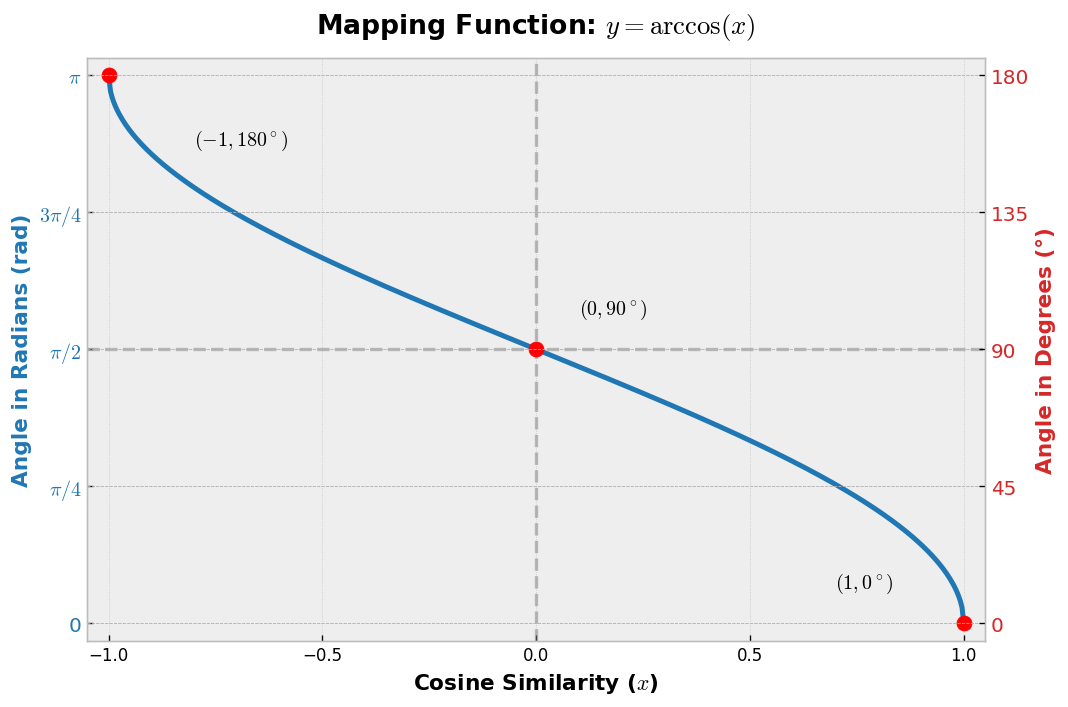

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# 设置更美观的样式
plt.style.use('bmh')

# 1. 生成数据
x = np.linspace(-1, 1, 500) # 横轴：余弦相似度 [-1, 1]
y_rad = np.arccos(x)        # 纵轴（左）：弧度 [0, π]
y_deg = np.rad2deg(y_rad)   # 纵轴（右）：角度 [0°, 180°]

# 2. 创建画布
fig, ax1 = plt.subplots(figsize=(9, 6), dpi=120)

# 3. 绘制主曲线 (以弧度为基准)
color_main = '#1f77b4'
ax1.plot(x, y_rad, color=color_main, linewidth=3, label=r'$y = \arccos(x)$')

# 设置横轴
ax1.set_xlabel('Cosine Similarity ($x$)', fontsize=13, fontweight='bold')
ax1.set_xlim([-1.05, 1.05])
ax1.set_xticks([-1, -0.5, 0, 0.5, 1])

# 设置左侧纵轴 (弧度)
ax1.set_ylabel('Angle in Radians (rad)', color=color_main, fontsize=13, fontweight='bold')
ax1.set_ylim([-0.1, np.pi + 0.1])
ax1.set_yticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
ax1.set_yticklabels(['0', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$'], color=color_main, fontsize=12)

# 4. 创建右侧共用横轴的副纵轴 (角度)
ax2 = ax1.twinx()
color_sec = '#d62728'
ax2.set_ylabel('Angle in Degrees (°)', color=color_sec, fontsize=13, fontweight='bold')
# 将弧度的 limits 转换为角度的 limits 以保持对齐
ax2.set_ylim([np.rad2deg(-0.1), np.rad2deg(np.pi + 0.1)])
ax2.set_yticks([0, 45, 90, 135, 180])
ax2.tick_params(axis='y', labelcolor=color_sec, labelsize=12)

# 5. 添加辅助线以突出关键节点 (1, 0), (0, 90), (-1, 180)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=np.pi/2, color='gray', linestyle='--', alpha=0.5)

# 标记关键点
points_x = [1, 0, -1]
points_y = [0, np.pi/2, np.pi]
ax1.scatter(points_x, points_y, color='red', s=80, zorder=5)

# 添加文本注释
ax1.annotate(r'$(1, 0^\circ)$', xy=(1, 0), xytext=(0.7, 0.2), 
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12)
ax1.annotate(r'$(0, 90^\circ)$', xy=(0, np.pi/2), xytext=(0.1, np.pi/2 + 0.2), 
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12)
ax1.annotate(r'$(-1, 180^\circ)$', xy=(-1, np.pi), xytext=(-0.8, np.pi - 0.4), 
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=12)

# 6. 收尾
plt.title(r'Mapping Function: $y = \arccos(x)$', fontsize=16, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [4]:
def robust_z(x):
    x = torch.tensor(x, dtype=torch.float32)
    med = x.median()
    mad = (x - med).abs().median().clamp_min(1e-12)
    return (0.6745 * (x - med) / mad).numpy()

df["log_norm_ratio"] = torch.log(torch.tensor(df["norm_ratio"].values)).numpy()
df["abs_norm_z"] = abs(robust_z(df["log_norm_ratio"].values))

df["sft_norm_pct"] = df["sft_norm"].rank(pct=True)
df["norm_change_pct"] = df["abs_norm_z"].rank(pct=True)
df["rel_l2_pct"] = df["rel_l2"].rank(pct=True)
df["cos_drop_pct"] = 1.0 - df["cos"].rank(pct=True)

df["glitch_score"] = (
    2.0 * df["norm_change_pct"] +
    1.5 * df["rel_l2_pct"] +
    1.0 * df["cos_drop_pct"] +
    0.5 * df["sft_norm_pct"]
)

$$
\text{token id}
\rightarrow
\text{vocab piece}
\rightarrow
\text{byte sequence}
\rightarrow
\text{UTF-8 text}
$$

In [58]:
def add_token_text(frame, tokenizer=tok):
    out = frame.copy()
    ids = out["id"].astype(int).tolist()
    # out["piece"] = [tokenizer.convert_ids_to_tokens(i) for i in ids]
    # out["piece"] = [
    #     tokenizer.decode([i], clean_up_tokenization_spaces=False)
    #     for i in ids
    # ]
    out["text"] = [
        repr(tokenizer.decode([i], clean_up_tokenization_spaces=False))
        for i in ids
    ]
    cols = [
        "id", "text", 
        # "piece",
        "base_norm", "sft_norm", "norm_ratio", "abs_norm_z",
        "cos", "angle_deg", "rel_l2", "glitch_score"
    ]
    return out[cols]

top_by_sft_norm = df.sort_values("sft_norm", ascending=False).head(60)
top_by_norm_change = df.sort_values("abs_norm_z", ascending=False).head(60)
top_by_l2 = df.sort_values("rel_l2", ascending=False).head(60)

# display(add_token_text(top_by_sft_norm))
display(add_token_text(top_by_norm_change))
display(add_token_text(top_by_l2))

,id,text,base_norm,sft_norm,norm_ratio,abs_norm_z,cos,angle_deg,rel_l2,glitch_score
151657,151657,'<tool_call>',0.414250,0.431250,1.041038,27.967470,0.967047,14.749727,0.265133,4.508978
151658,151658,'</tool_call>',0.414250,0.429003,1.035614,24.612959,0.962367,15.768679,0.281453,4.508889
115478,115478,'战战组合',0.421983,0.434148,1.028827,20.390764,0.969079,14.285423,0.253885,4.470893
116942,116942,'迷失传奇',0.443562,0.455647,1.027247,19.403584,0.972070,13.573362,0.241090,4.467026
122502,122502,'𦙶',0.413805,0.425011,1.027080,19.299469,0.969464,14.195656,0.251913,4.461826
151074,151074,'톧',0.412311,0.423434,1.026978,19.235365,0.970724,13.898323,0.246700,4.459265
117971,117971,'力还是自',0.418341,0.429612,1.026943,19.213970,0.968940,14.317649,0.254010,4.470692
142385,142385,' zwłas',0.417293,0.428531,1.026930,19.205921,0.968305,14.463963,0.256561,4.507961
143667,143667,' międzynar',0.425282,0.436734,1.026927,19.203981,0.971236,13.775662,0.244548,4.467391
128200,128200,'przedsięb',0.414072,0.425216,1.026914,19.195784,0.969028,14.297086,0.253645,4.469810


,id,text,base_norm,sft_norm,norm_ratio,abs_norm_z,cos,angle_deg,rel_l2,glitch_score
151658,151658,'</tool_call>',0.414250,0.429003,1.035614,24.612959,0.962367,15.768679,0.281453,4.508889
70564,70564,'\tNdrFc',0.420131,0.428559,1.020062,14.896278,0.963946,15.432219,0.271952,4.469748
151283,151283,'𖠚',0.430842,0.439645,1.020432,15.129182,0.965408,15.114163,0.266487,4.470926
74472,74472,'aincontri',0.431683,0.441982,1.023857,17.280968,0.965781,15.032099,0.265784,4.475218
150845,150845,'ꪻ',0.418235,0.426985,1.020922,15.437738,0.965672,15.056149,0.265577,4.470347
151657,151657,'<tool_call>',0.414250,0.431250,1.041038,27.967470,0.967047,14.749727,0.265133,4.508978
151298,151298,'𝇚',0.414385,0.424497,1.024401,17.622496,0.966198,14.939637,0.264291,4.467029
98844,98844,' davidjl',0.424212,0.434783,1.024919,17.946739,0.966335,14.909205,0.263875,4.476547
151299,151299,'𝇜',0.414355,0.424590,1.024701,17.810337,0.966456,14.882248,0.263356,4.467664
151297,151297,'𝇗',0.414745,0.425169,1.025134,18.081394,0.966750,14.816446,0.262305,4.475909


In [59]:
cand = cand[
    ((df["sft_norm_pct"] > 0.995) | (df["norm_change_pct"] > 0.995)) &
    ((df["rel_l2_pct"] > 0.990) | (df["cos_drop_pct"] > 0.990)) 
].copy()

cand = cand.sort_values("glitch_score", ascending=False)
cand_df = add_token_text(cand.head(200))
cand_df = cand_df[~cand_df["text"].fillna("").astype(str).str.strip().isin(["", "''", '""'])]
# display(cand_df)
cand_df.head(60)

/tmp/ipykernel_2839647/1958810237.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cand = cand[


,id,text,base_norm,sft_norm,norm_ratio,abs_norm_z,cos,angle_deg,rel_l2,glitch_score
151657,151657,'<tool_call>',0.414250,0.431250,1.041038,27.967470,0.967047,14.749727,0.265133,4.508978
151658,151658,'</tool_call>',0.414250,0.429003,1.035614,24.612959,0.962367,15.768679,0.281453,4.508889
142385,142385,' zwłas',0.417293,0.428531,1.026930,19.205921,0.968305,14.463963,0.256561,4.507961
115984,115984,'魔龙令牌',0.416386,0.427592,1.026914,19.195335,0.968479,14.423915,0.255858,4.507586
138174,138174,'Cumhurba',0.416077,0.427037,1.026342,18.837786,0.968265,14.473038,0.256585,4.507445
138175,138175,'Cumhurbaş',0.414918,0.425904,1.026477,18.922287,0.968344,14.455018,0.256301,4.507392
150901,150901,'둁',0.414812,0.425760,1.026391,18.868589,0.968249,14.476727,0.256660,4.507375
127734,127734,'פייסב',0.415023,0.426028,1.026517,18.947123,0.968396,14.443082,0.256102,4.507372
150869,150869,'깣',0.415158,0.426126,1.026418,18.885298,0.968428,14.435674,0.255950,4.507247
51088,51088,'�始化',0.414568,0.425485,1.026333,18.832266,0.968200,14.487981,0.256844,4.507214


In [56]:
def inspect_string(s):
    ids = tok.encode(s, add_special_tokens=False)
    rows = df.set_index("id").reindex(ids).reset_index()
    return add_token_text(rows)

display(inspect_string("嘉祺"))

,id,text,piece,base_norm,sft_norm,norm_ratio,abs_norm_z,cos,angle_deg,rel_l2,glitch_score
0,100731,'嘉',åĺī,1.006315,1.001018,0.994736,1.248271,0.999865,0.941284,0.017219,3.021702
1,115464,'祺',ç¥º,1.127431,1.124765,0.997635,0.620388,0.999730,1.330457,0.023327,3.330913


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = df.copy()

if "special" in plot_df.columns:
    plot_df = plot_df[~plot_df["special"]].copy()

plot_df["cos"] = plot_df["cos"].clip(-1.0, 1.0)

if "norm_ratio" not in plot_df.columns:
    plot_df["norm_ratio"] = plot_df["sft_norm"] / plot_df["base_norm"].clip(lower=1e-12)

plot_df["log_norm_ratio"] = np.log(plot_df["norm_ratio"].clip(lower=1e-12))
plot_df["cos_drop"] = (1.0 - plot_df["cos"]).clip(lower=0.0)

plot_df = plot_df.replace([np.inf, -np.inf], np.nan)

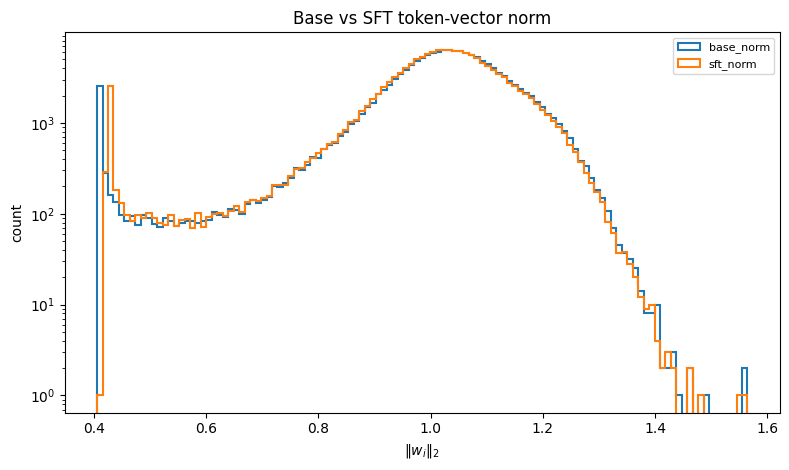

(<Figure size 800x480 with 1 Axes>,
 <Axes: title={'center': 'Base vs SFT token-vector norm'}, xlabel='$\\|w_i\\|_2$', ylabel='count'>)

In [9]:
def hist_norm_overlay(data, bins=120, log_y=True):
    x0 = data["base_norm"].dropna().to_numpy(dtype=float)
    x1 = data["sft_norm"].dropna().to_numpy(dtype=float)

    lo = min(x0.min(), x1.min())
    hi = max(x0.max(), x1.max())
    bins_used = np.linspace(lo, hi, bins)

    fig, ax = plt.subplots(figsize=(8, 4.8))

    ax.hist(x0, bins=bins_used, histtype="step", linewidth=1.5, label="base_norm")
    ax.hist(x1, bins=bins_used, histtype="step", linewidth=1.5, label="sft_norm")

    if log_y:
        ax.set_yscale("log")

    ax.set_title("Base vs SFT token-vector norm")
    ax.set_xlabel(r"$\|w_i\|_2$")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    return fig, ax


hist_norm_overlay(plot_df)

### misc

In [3]:
import torch
import re
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 仅加载模型底层，在 CPU 上加载 7B 会占用大约 14GB+ 内存
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="cpu")
embeddings = model.get_input_embeddings().weight.data # 维度: [152064, 3584]

# 计算所有 Token 向量的 L2 范数
norms = torch.norm(embeddings, p=2, dim=1)

# 1. 扩大候选池：找出范数最小的 Top 10000 个 Token 作为异常候选
k = 10000
smallest_norms, indices = torch.topk(norms, k, largest=False)

# 预编译正则，用于匹配中文字符
zh_pattern = re.compile(r'[\u4e00-\u9fa5]')

chinese_tokens_info = []

for i in range(k):
    token_id = indices[i].item()
    norm_val = smallest_norms[i].item()
    
    # 解码 token，遇到残缺字节用  替换
    token_str = tokenizer.decode([token_id], errors='replace')
    
    # 2. 过滤：找出包含中文的 token
    zh_chars = zh_pattern.findall(token_str)
    if zh_chars:
        # 记录该 token 包含的中文字符数量
        zh_len = len(zh_chars)
        
        # 也可以排除掉那些只有 1 个中文字符的单字，聚焦于“句子”
        if zh_len > 1:
            chinese_tokens_info.append({
                'id': token_id,
                'norm': norm_val,
                'str': token_str,
                'zh_len': zh_len
            })

# 3. 排序：优先按中文字符数量降序，如果长度相同，则按 L2 范数升序 (越异常越靠前)
chinese_tokens_info.sort(key=lambda x: (-x['zh_len'], x['norm']))

# 打印排名前 50 的异常长中文 Token
print(f"在 L2 范数最小的 {k} 个 Token 中，找到 {len(chinese_tokens_info)} 个多字中文 Token。")
print("排名前 50 的异常长序列如下：\n" + "-"*70)

for info in chinese_tokens_info[:50]:
    print(f"ID: {info['id']:<6} | Norm: {info['norm']:<7.4f} | 中文长度: {info['zh_len']:<2} | Token: {repr(info['str'])}")

Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/.no_exist/a09a35458c702b33eeacc393d103063234e8bc28/adapter_config.json'
ERROR:huggingface_hub.file_download:Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/.no_exist/a09a35458c702b33eeacc393d103063234e8bc28/adapter_config.json'
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models--Qwen--Qwen2.5-7B-Instruct/.no_exist/a09a35458c702b33eeacc393d103063234e8bc28/adapter_config.json'
ERROR:huggingface_hub.file_download:Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '/home/zhangchunhui/.cache/huggingface/hub/models

在 L2 范数最小的 10000 个 Token 中，找到 137 个多字中文 Token。
排名前 50 的异常长序列如下：
----------------------------------------------------------------------
ID: 117332 | Norm: 0.0150  | 中文长度: 4  | Token: '法战组合'
ID: 115984 | Norm: 0.0213  | 中文长度: 4  | Token: '魔龙令牌'
ID: 115992 | Norm: 0.0263  | 中文长度: 4  | Token: '鸟成长记'
ID: 115478 | Norm: 0.0291  | 中文长度: 4  | Token: '战战组合'
ID: 118326 | Norm: 0.0295  | 中文长度: 4  | Token: '凡本网注'
ID: 117971 | Norm: 0.0299  | 中文长度: 4  | Token: '力还是自'
ID: 117963 | Norm: 0.0315  | 中文长度: 4  | Token: '是韩国娱'
ID: 118754 | Norm: 0.0457  | 中文长度: 4  | Token: '主動註冊'
ID: 117938 | Norm: 0.0544  | 中文长度: 4  | Token: '身创造的'
ID: 103940 | Norm: 0.0548  | 中文长度: 4  | Token: '天空部落'
ID: 107754 | Norm: 0.0557  | 中文长度: 4  | Token: '會員規範'
ID: 116942 | Norm: 0.0671  | 中文长度: 4  | Token: '迷失传奇'
ID: 117769 | Norm: 0.0724  | 中文长度: 4  | Token: '精彩播报'
ID: 117975 | Norm: 0.0849  | 中文长度: 4  | Token: '具有战士'
ID: 109540 | Norm: 0.0899  | 中文长度: 4  | Token: '早餐加盟'
ID: 115963 | Norm: 0.0909  | 中文长度: 4  | Token: '天国继续'
I

In [4]:
vocab_size = tokenizer.vocab_size # 对于 Qwen2.5 通常是 151643 到 152064 之间

suspicious_tokens = []
for token_id in range(vocab_size):
    try:
        # 获取字节形式的 token
        token_bytes = tokenizer.convert_ids_to_tokens(token_id)
        if token_bytes is None:
            continue
            
        # 尝试解码为可读字符串
        token_str = tokenizer.decode([token_id])
        
        # 异常规则 1：长度过长（比如单个 token 超过 20 个中文字符）
        if len(token_str) > 20 and "<|" not in token_str: 
            suspicious_tokens.append((token_id, "Too Long", token_str))
            
    except Exception as e:
        # 异常规则 2：无法被 UTF-8 正常解码的残乱字节
        suspicious_tokens.append((token_id, "Undecodable", str(token_bytes)))

print(f"找到 {len(suspicious_tokens)} 个字面可疑 Token")

找到 410 个字面可疑 Token


In [6]:
suspicious_tokens[:10]

[(664, 'Too Long', '                       '),
 (786, 'Too Long', '                                '),
 (999, 'Too Long', '                           '),
 (1383, 'Too Long', '                               '),
 (1408, 'Too Long', '--------------------------------'),
 (1689, 'Too Long', '********************************'),
 (1920, 'Too Long', '                                   '),
 (2549, 'Too Long', '                     '),
 (2559, 'Too Long', '                                       '),
 (3058, 'Too Long', '================================')]